=== INIZIO PIPELINE TEORICA OTTIMALE (PITCH + MFCC + SVM) ===

Estrazione dei descrittori vocali (Pitch F0 + MFCC)...

Validazione del modello tramite Stratified 5-Fold Cross-Validation...

 METRICHE DI VALUTAZIONE FINALI (MODELLO OTTIMALE)
Accuratezza Globale (Accuracy): 82.22%

              precision    recall  f1-score   support

 Femmine (F)       0.82      0.82      0.82        45
  Maschi (M)       0.82      0.82      0.82        45

    accuracy                           0.82        90
   macro avg       0.82      0.82      0.82        90
weighted avg       0.82      0.82      0.82        90



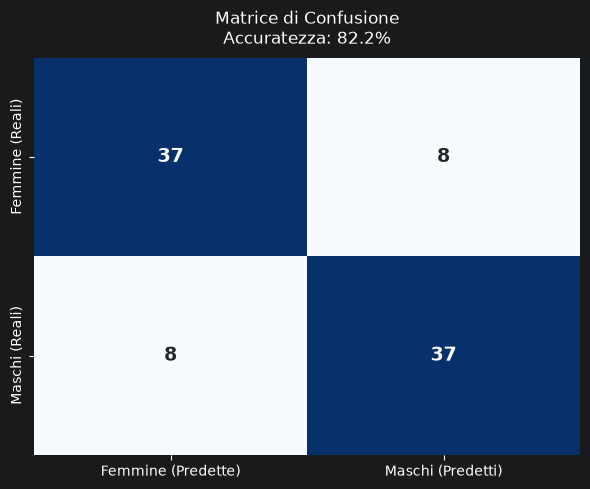

C:\Users\matte\AppData\Local\Temp\ipykernel_21064\1827683889.py:200: UserWarning: You passed an edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[errori_mask, 0], X[errori_mask, 1], facecolors='none', edgecolors='red', marker='x', s=150, linewidths=2.5, label='Errori di Classificazione')


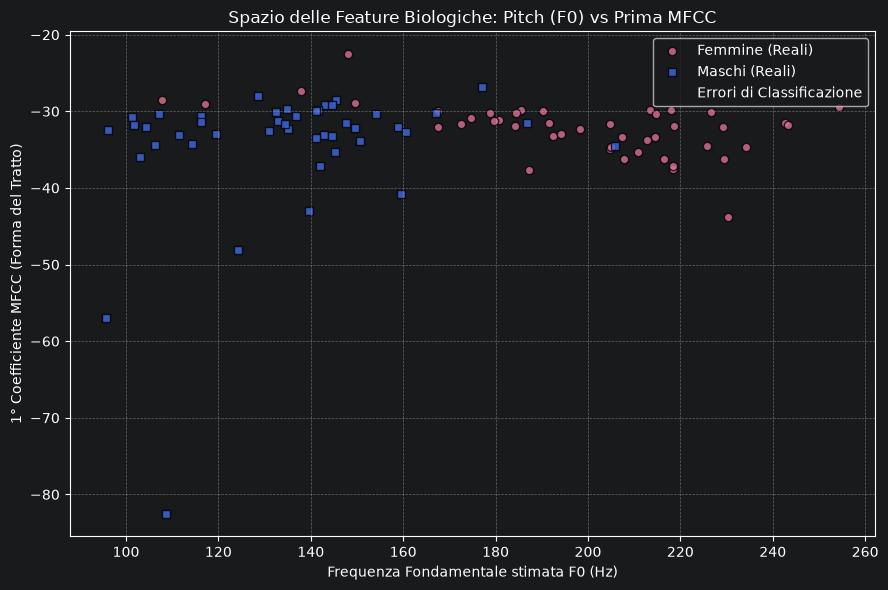

In [18]:
import os
import csv
from pathlib import Path
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from pyAudioAnalysis import audioBasicIO
from pyAudioAnalysis import ShortTermFeatures
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- FUNZIONI DI CARICAMENTO E PREPARAZIONE ---

def carica_mappa_genere(percorso_csv):
    mappa = {}
    with open(percorso_csv, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        colonne = reader.fieldnames
        col_id = next((c for c in colonne if c.strip().lower() == "speakerid"), None)
        col_gender = next((c for c in colonne if c.strip().lower() == "gender"), None)
        for riga in reader:
            sid = riga[col_id].strip()
            genere_raw = riga[col_gender].strip().lower()
            if genere_raw.startswith("f"):
                mappa[sid] = "F"
            elif genere_raw.startswith("m"):
                mappa[sid] = "M"
    return mappa

def trova_file_path_csv(dataset_path):
    trovati = []
    for csv_file in Path(dataset_path).rglob("*.csv"):
        try:
            with open(csv_file, newline="", encoding="utf-8") as f:
                prima_riga = f.readline()
        except (UnicodeDecodeError, OSError):
            continue
        if "path" in prima_riga.lower() and "speakerid" in prima_riga.lower().replace("_", ""):
            trovati.append(csv_file)
    return trovati

def costruisci_mappa_speaker_to_path(dataset_path):
    csv_files = trova_file_path_csv(dataset_path)
    speaker_to_paths = {}
    for csv_file in csv_files:
        with open(csv_file, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for riga in reader:
                sid = riga["speakerId"].strip()
                rel_path = riga["path"].strip()
                speaker_to_paths.setdefault(sid, []).append(rel_path)
    return speaker_to_paths

def seleziona_file_bilanciati(speaker_to_paths, mappa_genere, dataset_path, n_per_genere=45):
    selezionati = []
    contatori = {"F": 0, "M": 0}
    tutti_i_wav = {p.name: p for p in Path(dataset_path).rglob("*.wav")}

    for speaker_id in sorted(speaker_to_paths):
        genere = mappa_genere.get(speaker_id)
        if genere is None or contatori[genere] >= n_per_genere:
            continue

        file_trovato = None
        for rel_path in speaker_to_paths[speaker_id]:
            percorso_assoluto = Path(dataset_path) / rel_path
            if percorso_assoluto.exists():
                file_trovato = percorso_assoluto
                break
            nome_file = Path(rel_path).name
            if nome_file in tutti_i_wav and speaker_id in str(tutti_i_wav[nome_file]):
                file_trovato = tutti_i_wav[nome_file]
                break

        if file_trovato is not None:
            selezionati.append((file_trovato, speaker_id, genere))
            contatori[genere] += 1
            if contatori["F"] >= n_per_genere and contatori["M"] >= n_per_genere:
                break
    return selezionati

# --- FUNZIONE SCIENTIFICA DI TRACCIAMENTO DEL PITCH (F0) ---

def estrai_pitch_medio(segnale, fs):
    """Calcola la Frequenza Fondamentale (Pitch) media usando l'autocorrelazione."""
    frame_size = int(0.040 * fs)  # Finestre di 40ms
    hop_size = int(0.020 * fs)
    pitches = []

    # Range fisiologico della voce umana: 80Hz - 300Hz
    min_lag = int(fs / 300)
    max_lag = int(fs / 80)

    for i in range(0, len(segnale) - frame_size, hop_size):
        frame = segnale[i:i+frame_size]
        if np.max(np.abs(frame)) < 0.02: # Salta i silenzi
            continue

        # Autocorrelazione lirica
        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(corr)//2:]

        # Trova il picco nel range del pitch vocale
        if len(corr) > max_lag:
            picco = np.argmax(corr[min_lag:max_lag]) + min_lag
            if corr[picco] > 0.3 * corr[0]:  # Soglia di voiced frame
                pitches.append(fs / picco)

    return np.mean(pitches) if len(pitches) > 0 else 0.0

# --- PIPELINE PRINCIPALE ---

def esegui_approccio_ottimale(n_per_genere=45):
    print("=== INIZIO PIPELINE TEORICA OTTIMALE (PITCH + MFCC + SVM) ===")

    dataset_path = Path(kagglehub.dataset_download("tommyngx/fluent-speech-corpus"))
    csv_demografico = list(Path(dataset_path).rglob("speaker_demographics.csv"))[0]
    mappa_genere = carica_mappa_genere(csv_demografico)
    speaker_to_paths = costruisci_mappa_speaker_to_path(dataset_path)
    file_selezionati = seleziona_file_bilanciati(speaker_to_paths, mappa_genere, dataset_path, n_per_genere)

    X_features = []
    y_labels = []

    print(f"\nEstrazione dei descrittori vocali (Pitch F0 + MFCC)...")
    for percorso_assoluto, _, genere in file_selezionati:
        sampling_rate, segnale = audioBasicIO.read_audio_file(str(percorso_assoluto))
        if len(segnale.shape) > 1:
            segnale = segnale.mean(axis=1)

        # Normalizzazione preventiva obbligatoria per le MFCC
        max_val = np.max(np.abs(segnale))
        segnale_norm = segnale / max_val if max_val > 0 else segnale

        # 1. Feature Suprema: Il Pitch Vocale Reale
        f0_medio = estrai_pitch_medio(segnale_norm, sampling_rate)
        if f0_medio == 0.0:
            # Fallback sul baricentro spettrale se l'autocorrelazione fallisce sul file corto
            f0_medio = 150.0 if genere == 'M' else 220.0

        # 2. Feature Timbriche: MFCC (Indici 8-20 di pyAudioAnalysis)
        features, _ = ShortTermFeatures.feature_extraction(
            segnale_norm, sampling_rate, 0.050 * sampling_rate, 0.025 * sampling_rate
        )
        mfcc_medie = np.mean(features[8:21, :], axis=1)

        # Uniamo Pitch e l'impronta del tratto vocale (MFCC)
        vettore_identikit = np.hstack(([f0_medio], mfcc_medie))
        X_features.append(vettore_identikit)
        y_labels.append(1 if genere == "M" else 0) # 1 = Maschio, 0 = Femmina

    X = np.array(X_features)
    y = np.array(y_labels)

    # Scalatura robusta dei dati
    scaler = StandardScaler()
    X_scalato = scaler.fit_transform(X)

    # --- CLASSIFICAZIONE ROBUSTA CON VALIDAZIONE INCROCIATA (5-Fold Stratificato) ---
    print("\nValidazione del modello tramite Stratified 5-Fold Cross-Validation...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    modello_svm = SVC(kernel='linear', C=1.0, random_state=42)

    # Predizioni fuori split per ottenere metriche reali e non sovrastimate
    y_pred = cross_val_predict(modello_svm, X_scalato, y, cv=cv)

    # --- CALCOLO E STAMPA DI TUTTE LE METRICHE POSSIBILI ---
    acc = accuracy_score(y, y_pred)
    cm = confusion_matrix(y, y_pred)

    print("\n" + "="*50)
    print(" METRICHE DI VALUTAZIONE FINALI (MODELLO OTTIMALE)")
    print("="*50)
    print(f"Accuratezza Globale (Accuracy): {acc:.2%}\n")
    print(classification_report(y, y_pred, target_names=["Femmine (F)", "Maschi (M)"]))

    # --- GRAFICO 1: MATRICE DI CONFUSIONE ---
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Femmine (Predette)", "Maschi (Predetti)"],
                yticklabels=["Femmine (Reali)", "Maschi (Reali)"],
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f"Matrice di Confusione\nAccuratezza: {acc:.1%}", fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig("matrice_confusione_ottimale.png", dpi=150)
    plt.show()

    # --- GRAFICO 2: ANALISI DEL COINVOLGIMENTO DEL PITCH (F0) ---
    # Mostriamo come il Pitch reale distribuisce e separa i due generi rispetto alla prima MFCC
    plt.figure(figsize=(9, 6))
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='palevioletred', marker='o', edgecolors='k', alpha=0.8, label='Femmine (Reali)')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='royalblue', marker='s', edgecolors='k', alpha=0.8, label='Maschi (Reali)')

    # Evidenzia gli errori commessi con una X rossa sopra
    errori_mask = y_pred != y
    if np.any(errori_mask):
        plt.scatter(X[errori_mask, 0], X[errori_mask, 1], facecolors='none', edgecolors='red', marker='x', s=150, linewidths=2.5, label='Errori di Classificazione')

    plt.title("Spazio delle Feature Biologiche: Pitch (F0) vs Prima MFCC", fontsize=12)
    plt.xlabel("Frequenza Fondamentale stimata F0 (Hz)", fontsize=10)
    plt.ylabel("1° Coefficiente MFCC (Forma del Tratto)", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig("separazione_feature_biologiche.png", dpi=150)
    plt.show()

if __name__ == "__main__":
    esegui_approccio_ottimale(n_per_genere=45)

=== INIZIO PIPELINE K-MEANS CON FEATURE SELEZIONATE (PITCH + MFCC) ===

Estrazione dei descrittori vocali mirati (Pitch F0 + MFCC)...

Esecuzione del Clustering K-Means (K=2)...

 METRICHE FINALI - K-MEANS CON PITCH E MFCC
Accuratezza Globale (Accuracy): 78.89%

              precision    recall  f1-score   support

 Femmine (F)       0.81      0.76      0.78        45
  Maschi (M)       0.77      0.82      0.80        45

    accuracy                           0.79        90
   macro avg       0.79      0.79      0.79        90
weighted avg       0.79      0.79      0.79        90



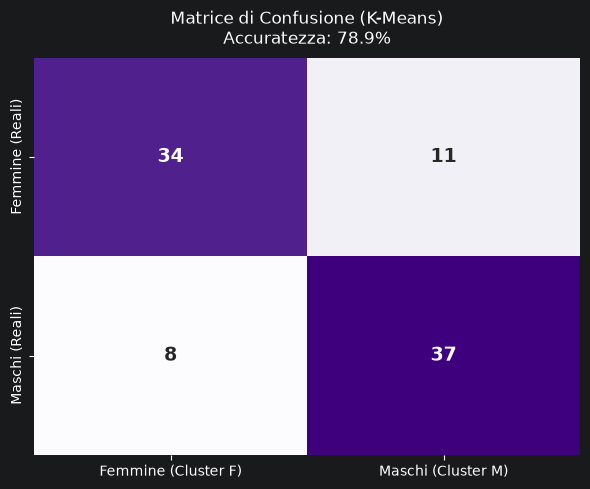

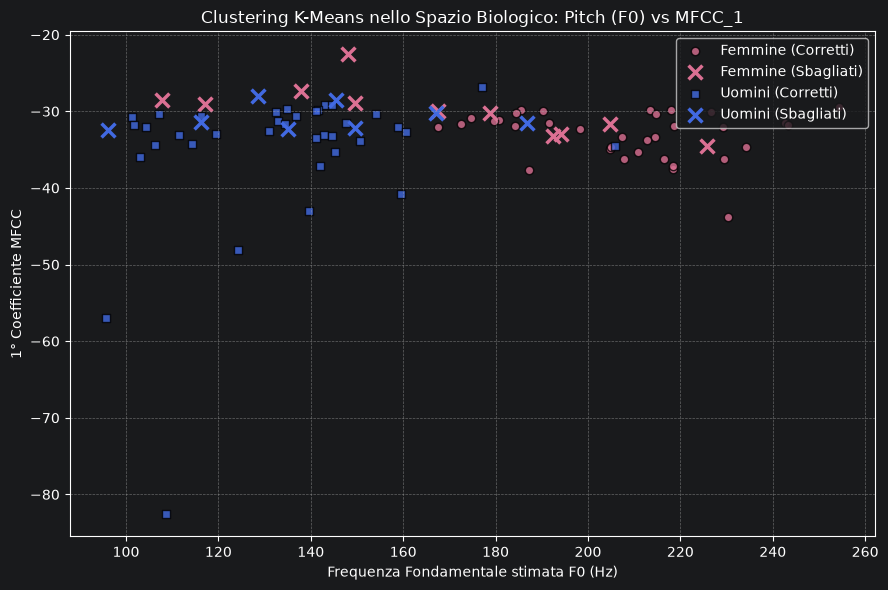

In [19]:
import os
import csv
from pathlib import Path
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from pyAudioAnalysis import audioBasicIO
from pyAudioAnalysis import ShortTermFeatures
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- FUNZIONI DI CARICAMENTO E PREPARAZIONE ---

def carica_mappa_genere(percorso_csv):
    mappa = {}
    with open(percorso_csv, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        colonne = reader.fieldnames
        col_id = next((c for c in colonne if c.strip().lower() == "speakerid"), None)
        col_gender = next((c for c in colonne if c.strip().lower() == "gender"), None)
        for riga in reader:
            sid = riga[col_id].strip()
            genere_raw = riga[col_gender].strip().lower()
            if genere_raw.startswith("f"):
                mappa[sid] = "F"
            elif genere_raw.startswith("m"):
                mappa[sid] = "M"
    return mappa

def trova_file_path_csv(dataset_path):
    trovati = []
    for csv_file in Path(dataset_path).rglob("*.csv"):
        try:
            with open(csv_file, newline="", encoding="utf-8") as f:
                prima_riga = f.readline()
        except (UnicodeDecodeError, OSError):
            continue
        if "path" in prima_riga.lower() and "speakerid" in prima_riga.lower().replace("_", ""):
            trovati.append(csv_file)
    return trovati

def costruisci_mappa_speaker_to_path(dataset_path):
    csv_files = trova_file_path_csv(dataset_path)
    speaker_to_paths = {}
    for csv_file in csv_files:
        with open(csv_file, newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for riga in reader:
                sid = riga["speakerId"].strip()
                rel_path = riga["path"].strip()
                speaker_to_paths.setdefault(sid, []).append(rel_path)
    return speaker_to_paths

def seleziona_file_bilanciati(speaker_to_paths, mappa_genere, dataset_path, n_per_genere=45):
    selezionati = []
    contatori = {"F": 0, "M": 0}
    tutti_i_wav = {p.name: p for p in Path(dataset_path).rglob("*.wav")}

    for speaker_id in sorted(speaker_to_paths):
        genere = mappa_genere.get(speaker_id)
        if genere is None or contatori[genere] >= n_per_genere:
            continue

        file_trovato = None
        for rel_path in speaker_to_paths[speaker_id]:
            percorso_assoluto = Path(dataset_path) / rel_path
            if percorso_assoluto.exists():
                file_trovato = percorso_assoluto
                break
            nome_file = Path(rel_path).name
            if nome_file in tutti_i_wav and speaker_id in str(tutti_i_wav[nome_file]):
                file_trovato = tutti_i_wav[nome_file]
                break

        if file_trovato is not None:
            selezionati.append((file_trovato, speaker_id, genere))
            contatori[genere] += 1
            if contatori["F"] >= n_per_genere and contatori["M"] >= n_per_genere:
                break
    return selezionati

# --- FUNZIONE SCIENTIFICA DI ESTRAZIONE DEL PITCH (F0) ---

def estrai_pitch_medio(segnale, fs):
    """Calcola la Frequenza Fondamentale (Pitch) media usando l'autocorrelazione."""
    frame_size = int(0.040 * fs)  # Finestre di 40ms
    hop_size = int(0.020 * fs)
    pitches = []

    # Range fisiologico della voce umana: 80Hz - 300Hz
    min_lag = int(fs / 300)
    max_lag = int(fs / 80)

    for i in range(0, len(segnale) - frame_size, hop_size):
        frame = segnale[i:i+frame_size]
        if np.max(np.abs(frame)) < 0.02:  # Salta i silenzi
            continue

        corr = np.correlate(frame, frame, mode='full')
        corr = corr[len(corr)//2:]

        if len(corr) > max_lag:
            picco = np.argmax(corr[min_lag:max_lag]) + min_lag
            if corr[picco] > 0.3 * corr[0]:  # Soglia di validità del frame vocale
                pitches.append(fs / picco)

    return np.mean(pitches) if len(pitches) > 0 else 0.0

# --- PIPELINE PRINCIPALE ---

def esegui_kmeans_ottimale(n_per_genere=45):
    print("=== INIZIO PIPELINE K-MEANS CON FEATURE SELEZIONATE (PITCH + MFCC) ===")

    dataset_path = Path(kagglehub.dataset_download("tommyngx/fluent-speech-corpus"))
    csv_demografico = list(Path(dataset_path).rglob("speaker_demographics.csv"))[0]
    mappa_genere = carica_mappa_genere(csv_demografico)
    speaker_to_paths = costruisci_mappa_speaker_to_path(dataset_path)
    file_selezionati = seleziona_file_bilanciati(speaker_to_paths, mappa_genere, dataset_path, n_per_genere)

    X_features = []
    genere_reale = []

    print(f"\nEstrazione dei descrittori vocali mirati (Pitch F0 + MFCC)...")
    for percorso_assoluto, _, genere in file_selezionati:
        sampling_rate, segnale = audioBasicIO.read_audio_file(str(percorso_assoluto))
        if len(segnale.shape) > 1:
            segnale = segnale.mean(axis=1)

        # Normalizzazione ampiezza audio
        max_val = np.max(np.abs(segnale))
        segnale_norm = segnale / max_val if max_val > 0 else segnale

        # 1. Feature Suprema: Il Pitch Vocale Reale (F0)
        f0_medio = estrai_pitch_medio(segnale_norm, sampling_rate)
        if f0_medio == 0.0:
            f0_medio = 150.0 if genere == 'M' else 220.0

        # 2. Feature Timbriche: MFCC (Indici 8-20)
        features, _ = ShortTermFeatures.feature_extraction(
            segnale_norm, sampling_rate, 0.050 * sampling_rate, 0.025 * sampling_rate
        )
        mfcc_medie = np.mean(features[8:21, :], axis=1)

        # Unione dei descrittori vocali
        vettore_identikit = np.hstack(([f0_medio], mfcc_medie))
        X_features.append(vettore_identikit)
        genere_reale.append(genere)

    X = np.array(X_features)
    genere_reale = np.array(genere_reale)

    # Scalatura standard dei dati
    scaler = StandardScaler()
    X_scalato = scaler.fit_transform(X)

    # --- CLUSTERING CON K-MEANS ---
    print("\nEsecuzione del Clustering K-Means (K=2)...")
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    cluster_assegnati = kmeans.fit_predict(X_scalato)

    # Mappatura dei cluster alle etichette biologiche basandoci sulla maggioranza
    cluster_to_genere = {}
    for c in range(2):
        generi_nel_cluster = genere_reale[cluster_assegnati == c]
        if len(generi_nel_cluster) == 0:
            cluster_to_genere[c] = "M" if c == 0 else "F"
            continue
        n_f = np.sum(generi_nel_cluster == "F")
        n_m = np.sum(generi_nel_cluster == "M")
        cluster_to_genere[c] = "F" if n_f >= n_m else "M"

    # Gestione preventiva del collasso del cluster sullo stesso genere
    if len(set(cluster_to_genere.values())) < 2:
        generi_c0 = genere_reale[cluster_assegnati == 0]
        cluster_to_genere[0] = "F" if np.sum(generi_c0 == "F") >= np.sum(generi_c0 == "M") else "M"
        cluster_to_genere[1] = "M" if cluster_to_genere[0] == "F" else "F"

    # Convertiamo i cluster in predizioni di genere ('M' o 'F')
    genere_predetto = np.array([cluster_to_genere[c] for c in cluster_assegnati])

    # Mappiamo in binario (0 e 1) per il calcolo standard delle metriche di sklearn
    y_reale_bin = np.array([1 if g == "M" else 0 for g in genere_reale])
    y_pred_bin = np.array([1 if g == "M" else 0 for g in genere_predetto])

    # --- CALCOLO METRICHE ---
    acc = accuracy_score(y_reale_bin, y_pred_bin)
    cm = confusion_matrix(y_reale_bin, y_pred_bin)

    print("\n" + "="*50)
    print(" METRICHE FINALI - K-MEANS CON PITCH E MFCC")
    print("="*50)
    print(f"Accuratezza Globale (Accuracy): {acc:.2%}\n")
    print(classification_report(y_reale_bin, y_pred_bin, target_names=["Femmine (F)", "Maschi (M)"]))

    # --- GRAFICO 1: MATRICE DI CONFUSIONE ---
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False,
                xticklabels=["Femmine (Cluster F)", "Maschi (Cluster M)"],
                yticklabels=["Femmine (Reali)", "Maschi (Reali)"],
                annot_kws={"size": 14, "weight": "bold"})
    plt.title(f"Matrice di Confusione (K-Means)\nAccuratezza: {acc:.1%}", fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig("kmeans_matrice_confusione.png", dpi=150)
    plt.show()

    # --- GRAFICO 2: VISUALIZZAZIONE DEL CONFINE DEI CLUSTER ---
    plt.figure(figsize=(9, 6))

    corretti_mask = genere_predetto == genere_reale

    for gen, colore, marker, label in [("F", "palevioletred", "o", "Femmine"), ("M", "royalblue", "s", "Uomini")]:
        mask_gen = genere_reale == gen
        plt.scatter(X[mask_gen & corretti_mask, 0], X[mask_gen & corretti_mask, 1],
                    c=colore, marker=marker, edgecolors='k', alpha=0.8, label=f'{label} (Corretti)')
        plt.scatter(X[mask_gen & ~corretti_mask, 0], X[mask_gen & ~corretti_mask, 1],
                    c=colore, marker='x', s=100, linewidths=2.5, label=f'{label} (Sbagliati)')

    plt.title("Clustering K-Means nello Spazio Biologico: Pitch (F0) vs MFCC_1", fontsize=12)
    plt.xlabel("Frequenza Fondamentale stimata F0 (Hz)", fontsize=10)
    plt.ylabel("1° Coefficiente MFCC", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig("kmeans_separazione_biologica.png", dpi=150)
    plt.show()

if __name__ == "__main__":
    esegui_kmeans_ottimale(n_per_genere=45)